In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/alzheimers_disease_data.csv')
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


In [ ]:
#dropando colunas desnecessarias
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)

In [ ]:
print(df.isnull()) #checando se não tem nenhum dado vazio

        Age  Gender  Ethnicity  EducationLevel    BMI  Smoking  \
0     False   False      False           False  False    False   
1     False   False      False           False  False    False   
2     False   False      False           False  False    False   
3     False   False      False           False  False    False   
4     False   False      False           False  False    False   
...     ...     ...        ...             ...    ...      ...   
2144  False   False      False           False  False    False   
2145  False   False      False           False  False    False   
2146  False   False      False           False  False    False   
2147  False   False      False           False  False    False   
2148  False   False      False           False  False    False   

      AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0                  False             False        False         False  ...   
1                  False             False        F

In [ ]:
#checando se tem alguma linha 'repetida' de acordo com o críterio da função
sum(df.duplicated())

0

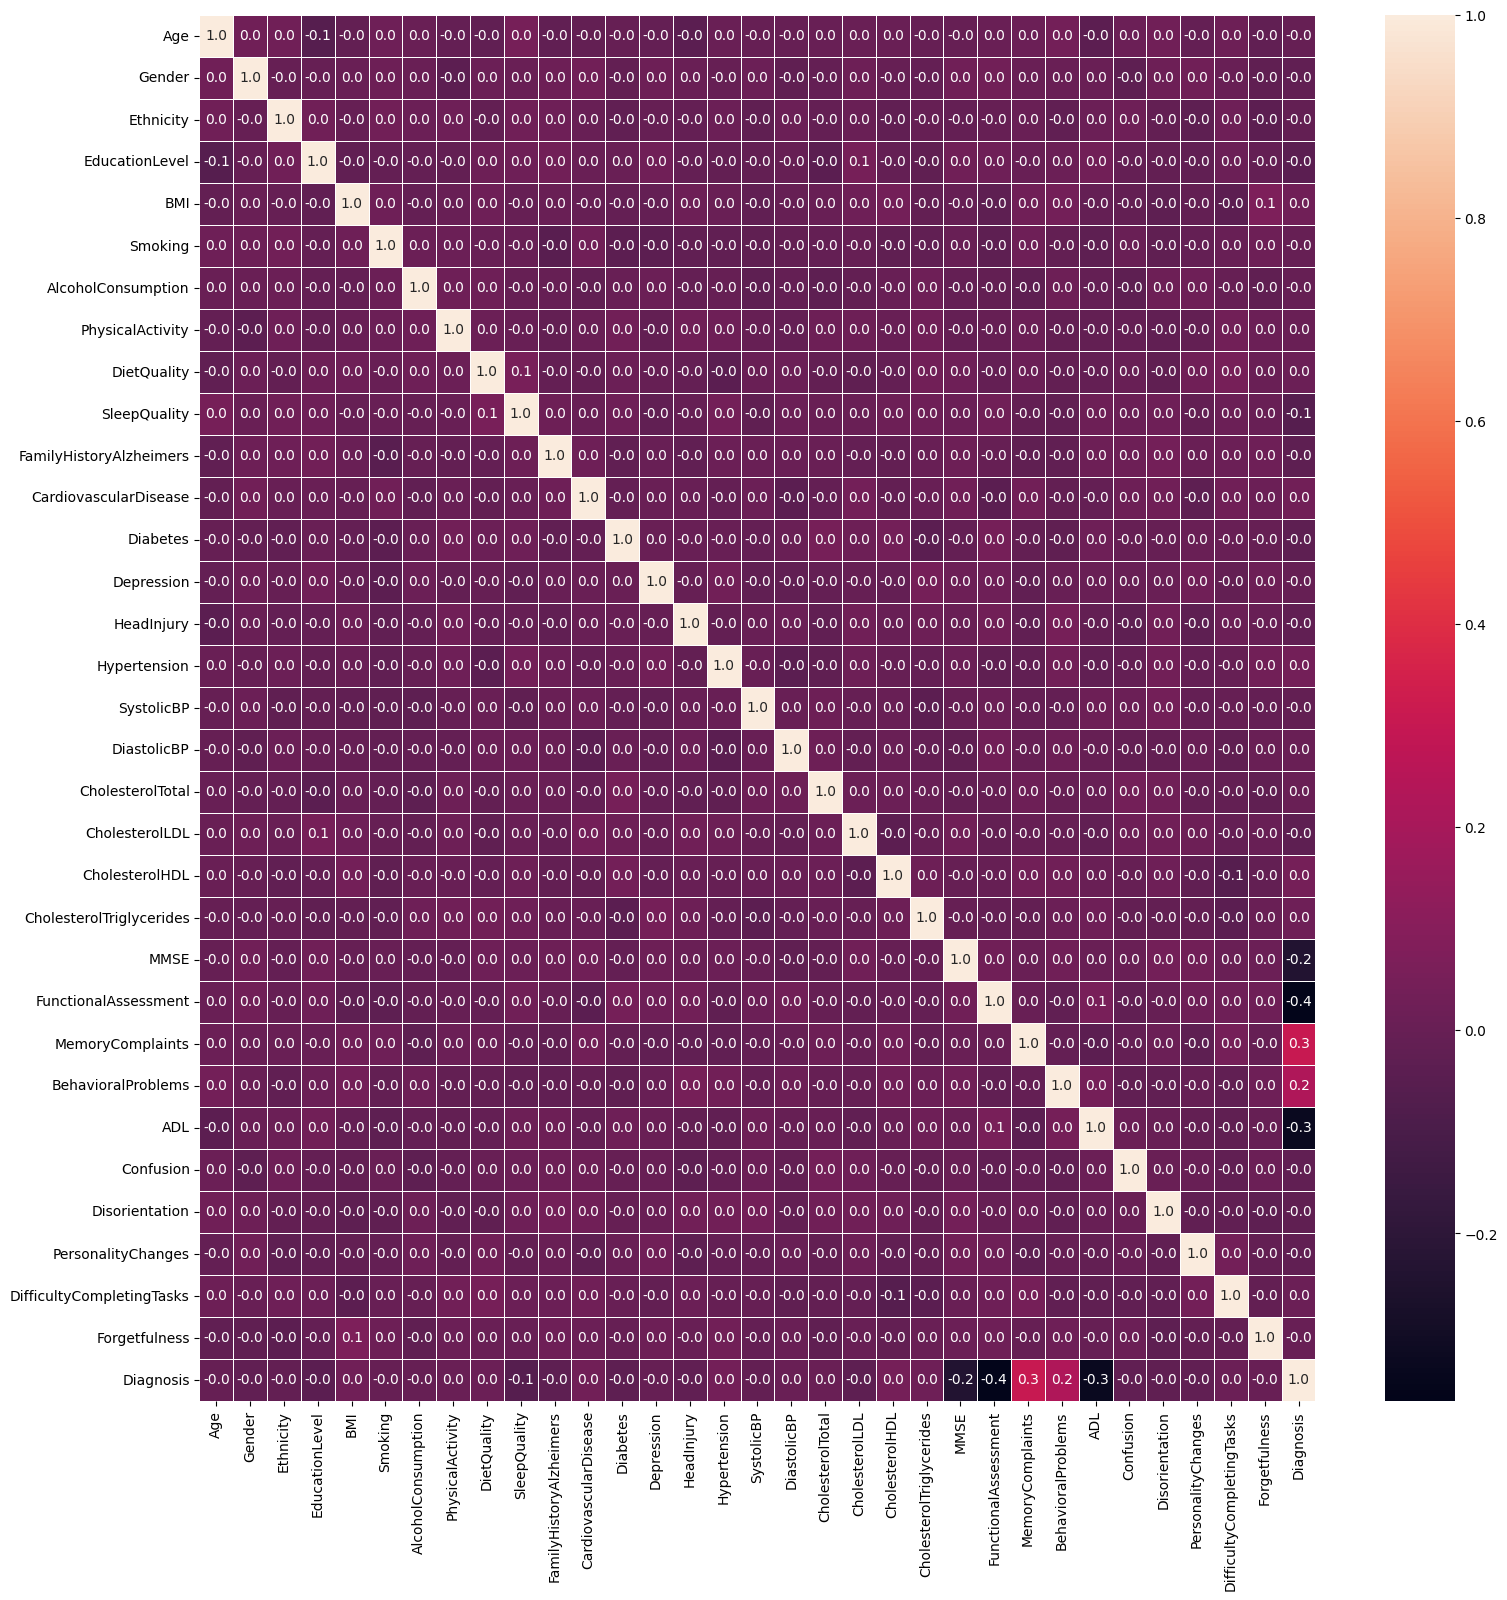

In [ ]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(df.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()

BALANCEAMENTO DA BASE DE DADOS

In [ ]:
df['Diagnosis'].value_counts()

,count
Diagnosis,
0,1389
1,760


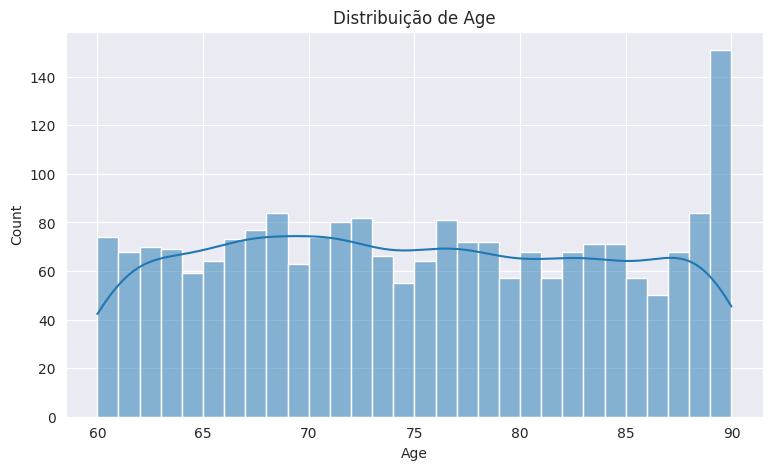

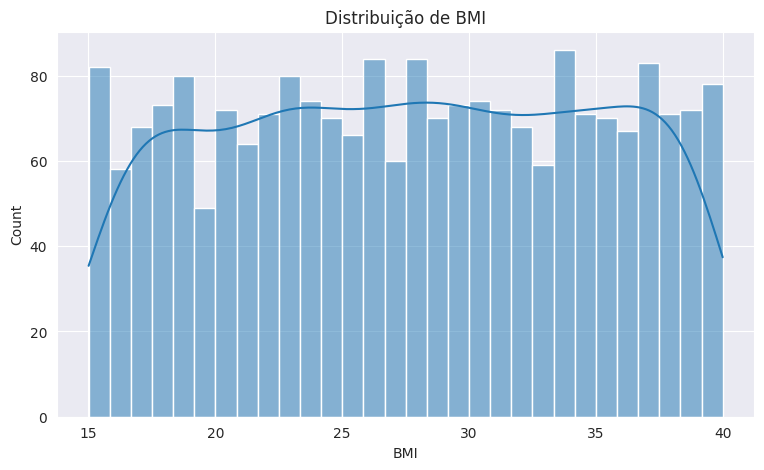

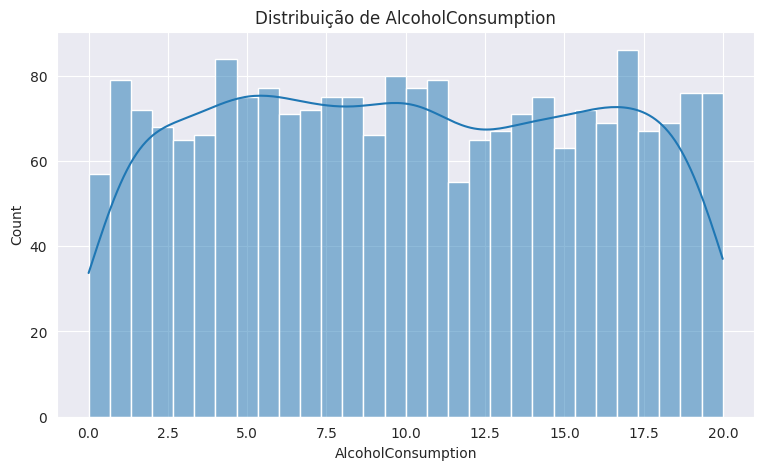

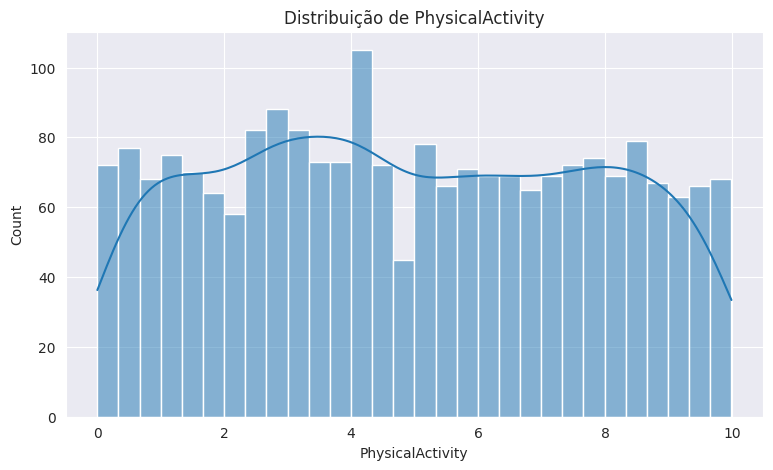

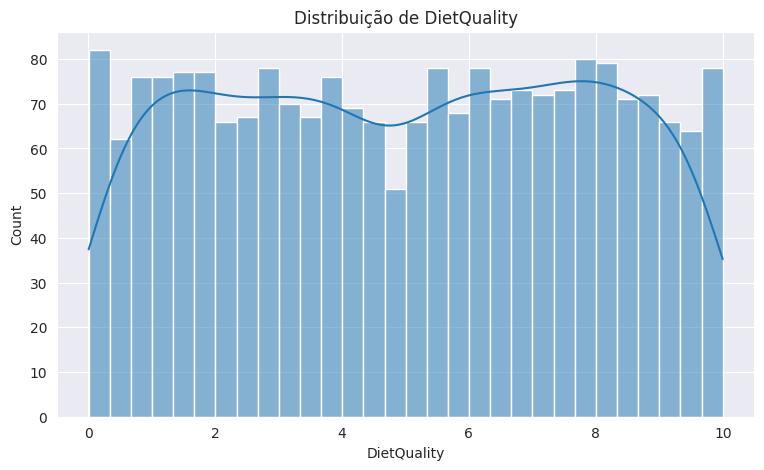

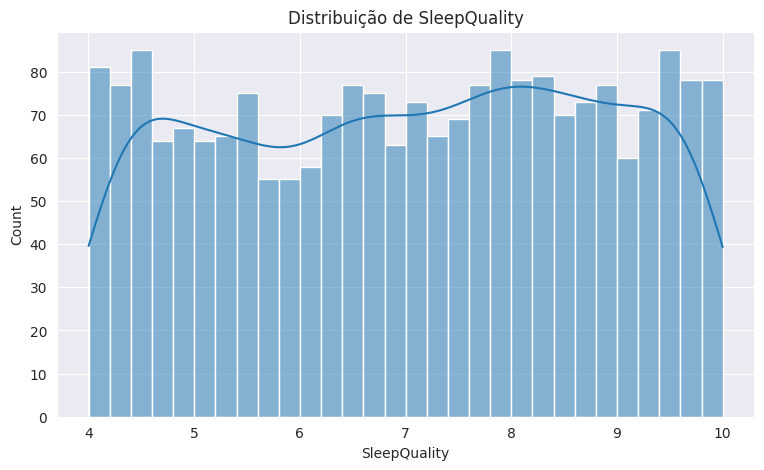

In [ ]:
columns_to_plot = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']


for column in columns_to_plot:
    sns.set_style("darkgrid")
    plt.figure(figsize=(9, 5))
    sns.histplot(data=df, x=column, kde=True, bins=30)
    plt.title(f'Distribuição de {column}')
    plt.show()

/tmp/ipykernel_579/969767480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnosis', ax=ax, palette=sns.color_palette("pastel"))
/tmp/ipykernel_579/969767480.py:10: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(data=df, x='Diagnosis', ax=ax, palette=sns.color_palette("pastel"))


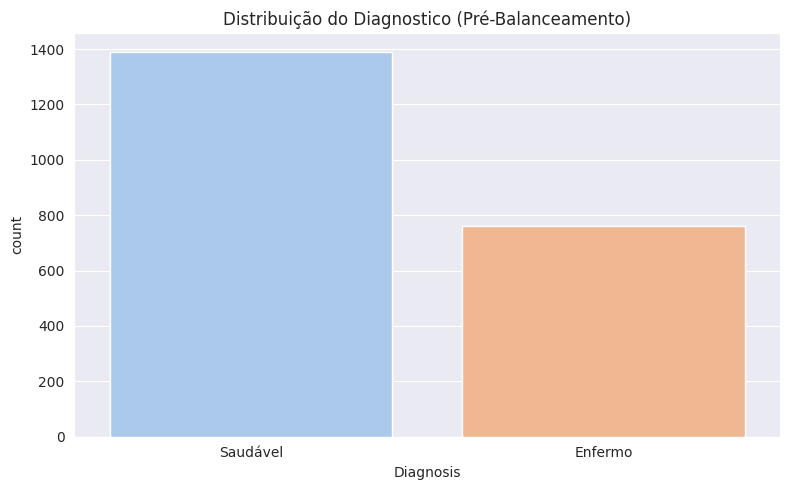

In [ ]:
# Setando as legendas
labels = ["Saudável", "Enfermo"]
ticks = range(len(labels))

# Cria uma figure
fig, ax = plt.subplots(figsize=(8, 5))

# Plotando o plot de conta
sns.set_style("darkgrid")
sns.countplot(data=df, x='Diagnosis', ax=ax, palette=sns.color_palette("pastel"))
ax.set_title('Distribuição do Diagnostico (Pré-Balanceamento)')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

# Ajustando o layout pra evitar overlapping (ficar um em cima do outro)
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.under_sampling import NearMiss

X, y = NearMiss().fit_resample(df.drop(columns=['Diagnosis']), df['Diagnosis'])

df = pd.DataFrame(X, columns=df.columns.drop('Diagnosis'))
df['Diagnosis'] = y
df

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,79,1,1,1,33.633101,0,9.866852,3.613764,8.336580,4.938171,...,5.746549,0,0,7.253777,0,0,0,0,1,0
1,82,0,0,2,29.513704,0,16.507030,0.752833,8.947017,8.375011,...,9.569407,0,0,5.122806,1,1,1,0,0,0
2,73,0,0,0,20.934329,1,10.782334,9.846122,7.706189,6.409516,...,5.575551,0,0,9.745211,0,0,0,0,0,0
3,71,1,1,1,37.674150,0,14.707459,9.031594,9.246871,6.479319,...,8.545265,0,1,6.250252,0,0,0,0,1,0
4,75,0,0,0,32.170070,1,19.484127,2.283416,2.915747,9.816984,...,5.164970,0,0,5.321710,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,66,1,2,1,32.013806,1,9.308706,4.352402,5.432374,9.624312,...,1.405821,0,0,4.544538,0,0,0,1,1,1
1516,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,...,0.238667,0,0,4.492838,1,0,0,0,0,1
1517,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,...,8.687480,0,1,9.204952,0,0,0,0,0,1
1518,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,...,1.972137,0,0,5.036334,0,0,0,0,0,1


/tmp/ipykernel_579/2654043737.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnosis', ax=ax, palette=sns.color_palette("pastel"))
/tmp/ipykernel_579/2654043737.py:10: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(data=df, x='Diagnosis', ax=ax, palette=sns.color_palette("pastel"))


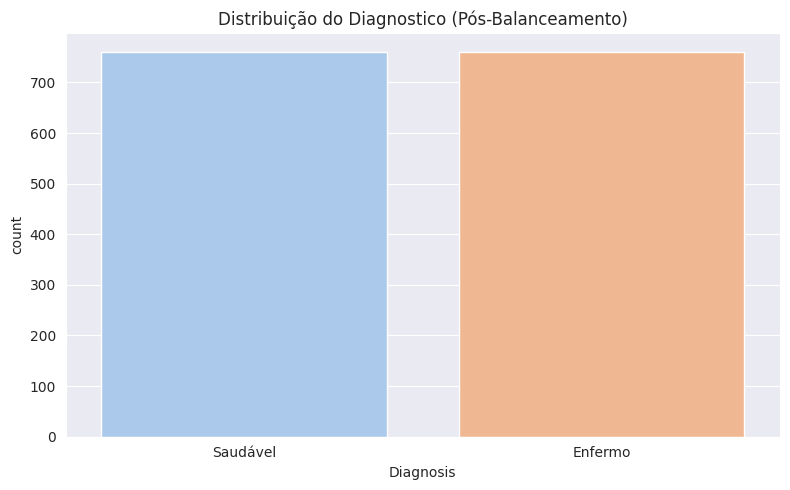

In [ ]:
# Setando as legendas
labels = ["Saudável", "Enfermo"]
ticks = range(len(labels))

# Cria uma figure
fig, ax = plt.subplots(figsize=(8, 5))

# Plotando o plot de conta
sns.set_style("darkgrid")
sns.countplot(data=df, x='Diagnosis', ax=ax, palette=sns.color_palette("pastel"))
ax.set_title('Distribuição do Diagnostico (Pós-Balanceamento)')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

# Ajustando o layout pra evitar overlapping (ficar um em cima do outro)
plt.tight_layout()
plt.show()

Treinando Classificadores

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Diagnosis']), df['Diagnosis'],test_size=0.30)

Rede Neural (MLP)

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(100, ), (7,)], #default e heurístico
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [200, 1000, 5000]
}

grid = GridSearchCV(MLPClassifier(),param_grid, verbose = 3, scoring='f1')
grid.fit(X_train,y_train)

pred = grid.predict(X_test)
print(metrics.classification_report(y_test, pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.618 total time=   0.2s
[CV 2/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.749 total time=   0.4s
[CV 3/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.782 total time=   0.2s
[CV 4/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.721 total time=   0.3s
[CV 5/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=200;, score=0.814 total time=   0.2s
[CV 1/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=1000;, score=0.803 total time=   0.3s
[CV 2/5] END activation=identity, hidden_layer_sizes=(100,), learning_rate_init=0.001, max_iter=1000;, score=0.821 total time=   0.1s
[CV 3

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.782 total time=   0.4s
[CV 2/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.857 total time=   0.3s
[CV 3/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.813 total time=   0.4s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 4/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.787 total time=   0.4s
[CV 5/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.805 total time=   0.2s
[CV 1/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.759 total time=   0.4s
[CV 2/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.820 total time=   0.4s
[CV 3/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.790 total time=   0.4s
[CV 4/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.793 total time=   0.4s
[CV 5/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.850 total time=   0.4s
[CV 1/5] END activation=identity, hidden_layer_sizes=(7,), learning_rate_init=

...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 4/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.812 total time=   0.4s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 5/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=200;, score=0.763 total time=   0.4s
[CV 1/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.795 total time=   0.7s
[CV 2/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.195 total time=   0.4s
[CV 3/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.781 total time=   0.4s
[CV 4/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.782 total time=   0.5s
[CV 5/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=1000;, score=0.816 total time=   0.9s
[CV 1/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=5000;, score=0.687 total time=   0.3s
[CV 2/5] END activation=relu, hidden_layer_sizes=(7,), learning_rate_init=0.001, max_iter=5000;, score=0.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
param_grid =  {'criterion' : ['gini','entropy'], 'splitter' : ['best', 'random'], 'max_depth' : list(range(3, 15)), 'max_features' : ["auto", "sqrt", "log2"], }

grid = GridSearchCV(DecisionTreeClassifier(),param_grid,verbose=3, scoring='f1')
grid.fit(X_train, y_train)
grid_predictions = grid.predict(X_test)

print(metrics.classification_report(y_test, grid_predictions))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, max_features=auto, splitter=random;, scor

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
240 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

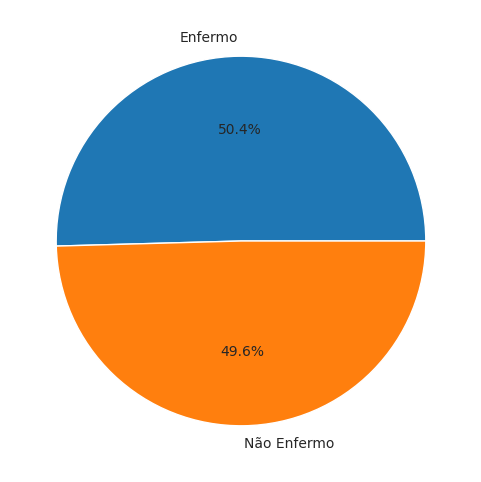

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(11,6))
df2 = pd.DataFrame(grid_predictions, columns = ['Diagnosis'])
sizes = df2['Diagnosis'].value_counts()
labels = ['Enfermo', 'Não Enfermo']
plt.pie(sizes, labels = labels, autopct='%1.1f%%')


plt.show()